In [20]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [21]:
## Loading the data
data = pd.read_csv('../data/ProcessedDataForTestModel/ResultsFrom1990.csv')
data

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
0,1992-03-21,Dominican Republic,Puerto Rico,1.0,2.0,FIFA World Cup qualification,Santo Domingo,Dominican Republic,False,1992
1,1992-03-22,Saint Lucia,Saint Vincent and the Grenadines,1.0,0.0,FIFA World Cup qualification,Castries,Saint Lucia,False,1992
2,1992-03-29,Puerto Rico,Dominican Republic,1.0,1.0,FIFA World Cup qualification,San Juan,Puerto Rico,False,1992
3,1992-03-29,Saint Vincent and the Grenadines,Saint Lucia,3.0,1.0,FIFA World Cup qualification,Kingstown,Saint Vincent and the Grenadines,False,1992
4,1992-04-19,Barbados,Trinidad and Tobago,1.0,2.0,FIFA World Cup qualification,Bridgetown,Barbados,False,1992
...,...,...,...,...,...,...,...,...,...,...
7544,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True,2026
7545,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True,2026
7546,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True,2026
7547,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True,2026


In [22]:
## Prepairing the features for training
important_columns = ['home_team', 'away_team', 'home_score', 'away_score', 'year', 'neutral']
data = data[important_columns].copy()
data

,home_team,away_team,home_score,away_score,year,neutral
0,Dominican Republic,Puerto Rico,1.0,2.0,1992,False
1,Saint Lucia,Saint Vincent and the Grenadines,1.0,0.0,1992,False
2,Puerto Rico,Dominican Republic,1.0,1.0,1992,False
3,Saint Vincent and the Grenadines,Saint Lucia,3.0,1.0,1992,False
4,Barbados,Trinidad and Tobago,1.0,2.0,1992,False
...,...,...,...,...,...,...
7544,Jordan,Argentina,NaN,NaN,2026,True
7545,Colombia,Portugal,NaN,NaN,2026,True
7546,DR Congo,Uzbekistan,NaN,NaN,2026,True
7547,Panama,England,NaN,NaN,2026,True


In [23]:
data.info()
## No nan values so we dont need to drop na values

<class 'pandas.DataFrame'>
RangeIndex: 7549 entries, 0 to 7548
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   home_team   7549 non-null   str    
 1   away_team   7549 non-null   str    
 2   home_score  7477 non-null   float64
 3   away_score  7477 non-null   float64
 4   year        7549 non-null   int64  
 5   neutral     7549 non-null   bool   
dtypes: bool(1), float64(2), int64(1), str(2)
memory usage: 302.4 KB


In [24]:
## Converting the neutral column to 0 or 1 depending on the bool value
data['neutral'] = data['neutral'].astype(int)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7549 entries, 0 to 7548
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   home_team   7549 non-null   str    
 1   away_team   7549 non-null   str    
 2   home_score  7477 non-null   float64
 3   away_score  7477 non-null   float64
 4   year        7549 non-null   int64  
 5   neutral     7549 non-null   int64  
dtypes: float64(2), int64(2), str(2)
memory usage: 354.0 KB


In [25]:
data

,home_team,away_team,home_score,away_score,year,neutral
0,Dominican Republic,Puerto Rico,1.0,2.0,1992,0
1,Saint Lucia,Saint Vincent and the Grenadines,1.0,0.0,1992,0
2,Puerto Rico,Dominican Republic,1.0,1.0,1992,0
3,Saint Vincent and the Grenadines,Saint Lucia,3.0,1.0,1992,0
4,Barbados,Trinidad and Tobago,1.0,2.0,1992,0
...,...,...,...,...,...,...
7544,Jordan,Argentina,NaN,NaN,2026,1
7545,Colombia,Portugal,NaN,NaN,2026,1
7546,DR Congo,Uzbekistan,NaN,NaN,2026,1
7547,Panama,England,NaN,NaN,2026,1


In [26]:
print("Number of matches after filtering:", len(data))
print("Years:", sorted(data["year"].unique()))
## The data has more years because we are taking into count the qualification match results as well

Number of matches after filtering: 7549
Years: [np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


In [27]:
## ENCODING TEAMS
## We have to change the team column to numeric values so our neural network can work with the data

all_teams = sorted(set(data['home_team']).union(set(data['away_team'])))
## This gets all teams that appear as home teams and all teams that appear as away teams, combines them, then sorts them alphabetically so the result is stable

team_to_id = {team: idx for idx, team in enumerate(all_teams)}
## Creating a dictionary to get all teams a unique numeric value

id_to_team = {idx: team for team, idx in team_to_id.items()}
## This is a dictionary for reversing the numbers to nations later


In [29]:
data['home_team_id'] = data['home_team'].map(team_to_id)
data['away_team_id'] = data['away_team'].map(team_to_id)
data

,home_team,away_team,home_score,away_score,year,neutral,home_team_id,away_team_id
0,Dominican Republic,Puerto Rico,1.0,2.0,1992,0,57,152
1,Saint Lucia,Saint Vincent and the Grenadines,1.0,0.0,1992,0,159,160
2,Puerto Rico,Dominican Republic,1.0,1.0,1992,0,152,57
3,Saint Vincent and the Grenadines,Saint Lucia,3.0,1.0,1992,0,160,159
4,Barbados,Trinidad and Tobago,1.0,2.0,1992,0,17,193
...,...,...,...,...,...,...,...,...
7544,Jordan,Argentina,NaN,NaN,2026,1,98,8
7545,Colombia,Portugal,NaN,NaN,2026,1,42,151
7546,DR Congo,Uzbekistan,NaN,NaN,2026,1,53,204
7547,Panama,England,NaN,NaN,2026,1,145,61


In [32]:
data = data.dropna()
data

,home_team,away_team,home_score,away_score,year,neutral,home_team_id,away_team_id
0,Dominican Republic,Puerto Rico,1.0,2.0,1992,0,57,152
1,Saint Lucia,Saint Vincent and the Grenadines,1.0,0.0,1992,0,159,160
2,Puerto Rico,Dominican Republic,1.0,1.0,1992,0,152,57
3,Saint Vincent and the Grenadines,Saint Lucia,3.0,1.0,1992,0,160,159
4,Barbados,Trinidad and Tobago,1.0,2.0,1992,0,17,193
...,...,...,...,...,...,...,...,...
7472,Iraq,Bolivia,2.0,1.0,2026,1,92,24
7473,Bosnia and Herzegovina,Italy,1.0,1.0,2026,0,25,94
7474,Sweden,Poland,3.0,2.0,2026,0,181,150
7475,Kosovo,Turkey,0.0,1.0,2026,0,101,195


In [34]:
num_teams = len(all_teams)

print("Number of teams:", num_teams)
print(team_to_id)
print(data[["home_team", "home_team_id", "away_team", "away_team_id"]].head())

Number of teams: 212
{'Afghanistan': 0, 'Albania': 1, 'Algeria': 2, 'American Samoa': 3, 'Andorra': 4, 'Angola': 5, 'Anguilla': 6, 'Antigua and Barbuda': 7, 'Argentina': 8, 'Armenia': 9, 'Aruba': 10, 'Australia': 11, 'Austria': 12, 'Azerbaijan': 13, 'Bahamas': 14, 'Bahrain': 15, 'Bangladesh': 16, 'Barbados': 17, 'Belarus': 18, 'Belgium': 19, 'Belize': 20, 'Benin': 21, 'Bermuda': 22, 'Bhutan': 23, 'Bolivia': 24, 'Bosnia and Herzegovina': 25, 'Botswana': 26, 'Brazil': 27, 'British Virgin Islands': 28, 'Brunei': 29, 'Bulgaria': 30, 'Burkina Faso': 31, 'Burundi': 32, 'Cambodia': 33, 'Cameroon': 34, 'Canada': 35, 'Cape Verde': 36, 'Cayman Islands': 37, 'Central African Republic': 38, 'Chad': 39, 'Chile': 40, 'China PR': 41, 'Colombia': 42, 'Comoros': 43, 'Congo': 44, 'Cook Islands': 45, 'Costa Rica': 46, 'Croatia': 47, 'Cuba': 48, 'Curaçao': 49, 'Cyprus': 50, 'Czech Republic': 51, 'Czechoslovakia': 52, 'DR Congo': 53, 'Denmark': 54, 'Djibouti': 55, 'Dominica': 56, 'Dominican Republic': 57, 

In [35]:
## Normalizing the year column
year_mean = data['year'].mean()
year_std = data['year'].std()

data['year_norm'] = (data['year'] - year_mean) / year_std

numeric_features = data[['year_norm', 'neutral']].values.astype(np.float32)

In [36]:
## Prepairing the team IDs
home_team_ids = data['home_team_id'].values.astype(np.int64)
away_team_ids = data['away_team_id'].values.astype(np.int64)

targets = data[['home_score', 'away_score']].values.astype(np.float32)

print("home_team_ids shape:", home_team_ids.shape)
print("away_team_ids shape:", away_team_ids.shape)
print("numeric_features shape:", numeric_features.shape)
print("targets shape:", targets.shape)

home_team_ids shape: (7477,)
away_team_ids shape: (7477,)
numeric_features shape: (7477, 2)
targets shape: (7477, 2)


In [37]:
data[[
    "home_team",
    "away_team",
    "home_team_id",
    "away_team_id",
    "year",
    "year_norm",
    "neutral",
    "home_score",
    "away_score"
]].head()

,home_team,away_team,home_team_id,away_team_id,year,year_norm,neutral,home_score,away_score
0,Dominican Republic,Puerto Rico,57,152,1992,-1.796285,0,1.0,2.0
1,Saint Lucia,Saint Vincent and the Grenadines,159,160,1992,-1.796285,0,1.0,0.0
2,Puerto Rico,Dominican Republic,152,57,1992,-1.796285,0,1.0,1.0
3,Saint Vincent and the Grenadines,Saint Lucia,160,159,1992,-1.796285,0,3.0,1.0
4,Barbados,Trinidad and Tobago,17,193,1992,-1.796285,0,1.0,2.0


In [38]:
## Converting the data to PyTorch tensors and creating a test train split

indices = np.arange(len(data))
## So we need to make sure that when we split into training and test data, 
## row 0 from home_team_ids stays matched with row 0 from away_team_ids, numeric_features, and targets.

## Splitting indices into training and test sets

train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, shuffle=True)
## This assures that 80% of matches go to train data and 20% to test data

## Converting to TENSORS
## Training tensors
X_home_train = torch.tensor(home_team_ids[train_idx], dtype=torch.long) 
X_away_train = torch.tensor(away_team_ids[train_idx], dtype=torch.long)
X_num_train = torch.tensor(numeric_features[train_idx], dtype=torch.float32)
y_train = torch.tensor(targets[train_idx], dtype=torch.float32)

##Test tensors
X_home_test = torch.tensor(home_team_ids[test_idx], dtype=torch.long)
X_away_test = torch.tensor(away_team_ids[test_idx], dtype=torch.long)
X_num_test = torch.tensor(numeric_features[test_idx], dtype=torch.float32)
y_test = torch.tensor(targets[test_idx], dtype=torch.float32)



In [39]:
## Creating the TORCH datasets:
train_dataset = TensorDataset(
    X_home_train,
    X_away_train,
    X_num_train,
    y_train
)

test_dataset = TensorDataset(
    X_home_test,
    X_away_test,
    X_num_test,
    y_test
)

In [43]:
## Creating the data loaders
## DataLoader feeds the model with small groups of matches called batches

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True
)

In [44]:
## Checking if everything works
print("Training matches:", len(train_dataset))
print("Test matches:", len(test_dataset))

for batch in train_loader:
    home_ids, away_ids, numeric, y = batch
    
    print("home_ids shape:", home_ids.shape)
    print("away_ids shape:", away_ids.shape)
    print("numeric shape:", numeric.shape)
    print("target shape:", y.shape)
    break

Training matches: 5981
Test matches: 1496
home_ids shape: torch.Size([16])
away_ids shape: torch.Size([16])
numeric shape: torch.Size([16, 2])
target shape: torch.Size([16, 2])


In [83]:
## Defining the model

class ExpectedGoalsModel(nn.Module):
    def __init__(self, num_teams, embedding_dim=8, num_numeric_features = 2):
        super().__init__()
        
        self.team_embedding = nn.Embedding(num_teams, embedding_dim)
        input_dim = 2*embedding_dim + num_numeric_features

        self.network = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, home_team_ids, away_team_ids, numeric_features):
        ## Converting team ids into embedding vectors

        home_emb = self.team_embedding(home_team_ids)
        away_emb = self.team_embedding(away_team_ids)

        ## Join everything into one input vector

        x = torch.cat([home_emb, away_emb, numeric_features], dim=1)
        
        ## Neural network output before positivity constraint
        raw_output = self.network(x)

        ## Expected goals must be positive
        lambdas = F.softplus(raw_output)+1e-6

        return lambdas


In [84]:
## Create the model
device  = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print("Using device: ", device)

model = ExpectedGoalsModel(
    num_teams=num_teams,
    embedding_dim=4,
    num_numeric_features=2
).to(device)

print(model)

Using device:  cuda
ExpectedGoalsModel(
  (team_embedding): Embedding(212, 4)
  (network): Sequential(
    (0): Linear(in_features=10, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)


In [85]:
## Test one forward pass
for batch in train_loader:
    home_ids, away_ids, numeric, y = batch

    home_ids = home_ids.to(device)
    away_ids = away_ids.to(device)
    numeric = numeric.to(device)
    y = y.to(device)

    output = model(home_ids, away_ids, numeric)
    output = model(home_ids, away_ids, numeric)

    print("Model output shape:", output.shape)
    print("Target shape:", y.shape)

    print("Model output example:")
    print(output[:5])

    print("Target example:")
    print(y[:5])

    break


Model output shape: torch.Size([16, 2])
Target shape: torch.Size([16, 2])
Model output example:
tensor([[0.6401, 0.7113],
        [0.6366, 0.6584],
        [0.6245, 0.7057],
        [0.6686, 0.7165],
        [0.6339, 0.7153]], device='cuda:0', grad_fn=<SliceBackward0>)
Target example:
tensor([[2., 1.],
        [1., 1.],
        [0., 3.],
        [3., 1.],
        [3., 0.]], device='cuda:0')


In [86]:
## Defining the loss function and optimizer
loss_fn = nn.PoissonNLLLoss(log_input=False)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 1e-3
)

In [87]:
## Training function

def train_one_epoch(model, train_loader, optimizer, loss_fn):
    model.train()

    total_loss = 0.0

    for home_ids, away_ids, numeric, y in train_loader:
        home_ids = home_ids.to(device)
        away_ids = away_ids.to(device)
        numeric = numeric.to(device)
        y = y.to(device)

        predicted_lambdas = model(home_ids, away_ids, numeric)

        loss = loss_fn(predicted_lambdas, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(home_ids)
    average_loss = total_loss / len(train_loader.dataset)

    return average_loss



In [88]:
## Evaluation function

def evaluate(model, data_loader, loss_fn):
    model.eval()

    total_loss = 0.0

    with torch.no_grad():
        for home_ids, away_ids, numeric, y in data_loader:
            home_ids = home_ids.to(device)
            away_ids = away_ids.to(device)
            numeric = numeric.to(device)
            y = y.to(device)

            predicted_lambdas = model(home_ids, away_ids, numeric)

            loss = loss_fn(predicted_lambdas, y)

            total_loss += loss.item() * len(home_ids)

    average_loss = total_loss / len(data_loader.dataset)

    return average_loss

In [89]:
# Training the model
num_epochs = 100

train_losses = []
test_losses = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
    test_loss = evaluate(model, test_loader, loss_fn)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    print(
        f"Epoch {epoch } | "
        f"Train loss: {train_loss:.4f} | "
        f"Test loss: {test_loss:.4f}"
        )

Epoch 0 | Train loss: 0.9533 | Test loss: 0.9007
Epoch 1 | Train loss: 0.8745 | Test loss: 0.8844
Epoch 2 | Train loss: 0.8544 | Test loss: 0.8698
Epoch 3 | Train loss: 0.8331 | Test loss: 0.8523
Epoch 4 | Train loss: 0.8100 | Test loss: 0.8314
Epoch 5 | Train loss: 0.7866 | Test loss: 0.8146
Epoch 6 | Train loss: 0.7656 | Test loss: 0.7916
Epoch 7 | Train loss: 0.7451 | Test loss: 0.7742
Epoch 8 | Train loss: 0.7282 | Test loss: 0.7589
Epoch 9 | Train loss: 0.7134 | Test loss: 0.7428
Epoch 10 | Train loss: 0.7000 | Test loss: 0.7279
Epoch 11 | Train loss: 0.6867 | Test loss: 0.7185
Epoch 12 | Train loss: 0.6751 | Test loss: 0.7016
Epoch 13 | Train loss: 0.6642 | Test loss: 0.6894
Epoch 14 | Train loss: 0.6542 | Test loss: 0.6826
Epoch 15 | Train loss: 0.6464 | Test loss: 0.6741
Epoch 16 | Train loss: 0.6384 | Test loss: 0.6674
Epoch 17 | Train loss: 0.6314 | Test loss: 0.6621
Epoch 18 | Train loss: 0.6254 | Test loss: 0.6550
Epoch 19 | Train loss: 0.6184 | Test loss: 0.6518
Epoch 20 |

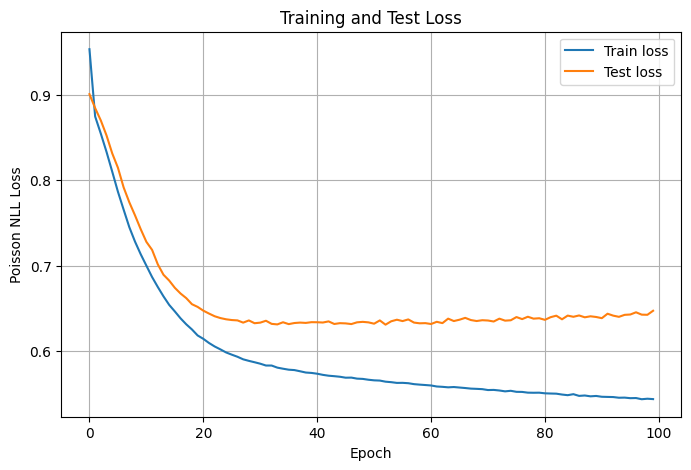

In [ ]:
## Plotting the training curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train loss")
plt.plot(test_losses, label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Poisson NLL Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.show()
## We can see that the best number of epochs is about 20-35

In [91]:
## Creating a prediction function
def predict_expected_goals(team1, team2, year, neutral=1):
    model.eval()

    if team1 not in team_to_id:
        raise ValueError(f"Unknown team: {team1}")

    if team2 not in team_to_id:
        raise ValueError(f"Unknown team: {team2}")

    team1_id = torch.tensor([team_to_id[team1]], dtype=torch.long).to(device)
    team2_id = torch.tensor([team_to_id[team2]], dtype=torch.long).to(device)

    year_norm = (year - year_mean) / year_std

    numeric = torch.tensor(
        [[year_norm, neutral]],
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():
        lambdas = model(team1_id, team2_id, numeric)

    lambda_team1 = lambdas[0, 0].item()
    lambda_team2 = lambdas[0, 1].item()

    return lambda_team1, lambda_team2

In [92]:
import math

def poisson_pmf(k, lam):
    return math.exp(-lam) * lam**k / math.factorial(k)


def outcome_probabilities(lambda_1, lambda_2, max_goals=10):
    p_team1_win = 0.0
    p_draw = 0.0
    p_team2_win = 0.0

    score_probs = {}

    for g1 in range(max_goals + 1):
        for g2 in range(max_goals + 1):
            p_score = poisson_pmf(g1, lambda_1) * poisson_pmf(g2, lambda_2)

            score_probs[(g1, g2)] = p_score

            if g1 > g2:
                p_team1_win += p_score
            elif g1 == g2:
                p_draw += p_score
            else:
                p_team2_win += p_score

    total = p_team1_win + p_draw + p_team2_win

    return {
        "team1_win": p_team1_win / total,
        "draw": p_draw / total,
        "team2_win": p_team2_win / total,
        "score_probs": score_probs
    }

In [93]:
## Full match prediction:
def predict_match(team1, team2, year=2026, neutral=1, max_goals=10):
    lambda_1, lambda_2 = predict_expected_goals(
        team1=team1,
        team2=team2,
        year=year,
        neutral=neutral
    )

    probs = outcome_probabilities(
        lambda_1=lambda_1,
        lambda_2=lambda_2,
        max_goals=max_goals
    )

    print(f"{team1} vs {team2}")
    print()
    print("Predicted expected goals:")
    print(f"{team1}: {lambda_1:.3f}")
    print(f"{team2}: {lambda_2:.3f}")

    print()
    print("Outcome probabilities:")
    print(f"{team1} win: {probs['team1_win']:.3f}")
    print(f"Draw: {probs['draw']:.3f}")
    print(f"{team2} win: {probs['team2_win']:.3f}")
    print()

    return {
        "lambda_team1": lambda_1,
        "lambda_team2": lambda_2,
        "team1_win_prob": probs["team1_win"],
        "draw_prob": probs["draw"],
        "team2_win_prob": probs["team2_win"],
        "score_probs": probs["score_probs"]
    }

result = predict_match(
    team1="Brazil",
    team2="Germany",
    year=2026,
    neutral=1
)

Brazil vs Germany

Predicted expected goals:
Brazil: 1.036
Germany: 1.987

Outcome probabilities:
Brazil win: 0.192
Draw: 0.214
Germany win: 0.594

